# FRPT Image Classification Result Processing

This notebook turns saved `.pt` runs into paper-ready result tables, supplementary statistical tests, and ablation figures.

Statistical convention used below: seed-paired one-sided tests are run for the bolded best entry within each `(model, layers, metric)` block. If the best setting uses `alpha > 0`, it is compared with `alpha = 0`; if `alpha = 0` is best, it is compared with the second-best setting. Supplementary tables report paired t-test p-values, Wilcoxon p-values, paired effect size `d_z`, and bootstrap confidence intervals where available.


In [1]:
%matplotlib inline
from IPython.display import display, Markdown
import math
import re
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/home/dn/.tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
# ---------- Configuration ----------
# Edit only these values for most paper tables.
DATASET_ORDER = ["mnist", "cifar10", "cifar100", "nette", "woof", "tin"]
DATASET_LABELS = {
    "mnist": "MNIST", "cifar10": "CIFAR-10", "cifar100": "CIFAR-100",
    "nette": "Imagenette", "woof": "Imagewoof", "tin": "Tiny-ImageNet",
}
MODEL_LABELS = {
    "simplecnnv1": "SimpleCNN-V1", "simplecnnv2": "SimpleCNN", "resnet18": "ResNet-18",
    "resnet34": "ResNet-34", "simplevit": "SimpleViT", "vit": "ViT",
}
# Optional publication-facing aliases for layers. Keys can be global recons keys or (model_family, recons_key).
# Example: LAYER_LABELS[("SimpleCNN", "recons_z4")] = "4"
LAYER_LABELS = {}
DEFAULT_MAIN_METRICS = ["epoch5_testacc", "mean_testacc", "best_testacc"]
DEFAULT_SUPP_METRICS = ["best_testacc", "mean_testacc", "epoch1_testacc", "epoch5_testacc", "epoch10_testacc"]
OOD_METRICS = ["overall_acc", "target_class_acc", "non_target_acc", "target_gain", "forgetting"]

ROW_END = r" \\"
HIGHER_IS_BETTER = {
    "best_testacc": True, "mean_testacc": True, "epoch1_testacc": True, "epoch5_testacc": True,
    "epoch10_testacc": True, "overall_acc": True, "target_class_acc": True,
    "non_target_acc": True, "target_gain": True, "forgetting": False,
}

def as_float_or_nan(value):
    try:
        return float(value) if value is not None else np.nan
    except (TypeError, ValueError):
        return np.nan

def _safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def infer_dataset_from_path(path):
    path = Path(path)
    parts = path.parts
    for ds in DATASET_ORDER:
        if ds in parts:
            return ds
    stem = path.stem.lower()
    if stem.startswith("ab_ma_"):
        stem = stem[6:]
    elif stem.startswith("ab_"):
        stem = stem[3:]
    if stem.startswith("mn_") or stem.startswith("mnist"):
        return "mnist"
    if stem.startswith("ci10_") or "cifar10" in stem:
        return "cifar10"
    if stem.startswith("ci100_") or "cifar100" in stem:
        return "cifar100"
    if stem.startswith("nette_") or "imagenette" in stem:
        return "nette"
    if stem.startswith("woof_") or "imagewoof" in stem:
        return "woof"
    if stem.startswith("tin_") or "timnet" in stem or "tiny" in stem:
        return "tin"
    return path.parent.name

def infer_variant_from_path(path):
    stem = Path(path).stem
    if "postreplay" in stem or "rr0.5" in stem:
        return "postreplay0.5"
    if "alltrain" in stem:
        return "alltrain"
    return "standard"

def model_family(model_name):
    name = str(model_name).lower()
    if "simplecnnv1" in name:
        return MODEL_LABELS["simplecnnv1"]
    if "simplecnnv2" in name or "simplecnn" in name:
        return MODEL_LABELS["simplecnnv2"]
    if "resnet34" in name:
        return MODEL_LABELS["resnet34"]
    if "resnet18" in name or "resnet" in name:
        return MODEL_LABELS["resnet18"]
    if "simplevit" in name or "vit_" in name or name.startswith("vit"):
        return MODEL_LABELS["simplevit"]
    return str(model_name)

MODEL_FAMILY_ORDER = {
    "SimpleCNN-V1": 0, "SimpleCNN": 0,
    "ResNet-18": 1, "ResNet-34": 1,
    "SimpleViT": 2, "ViT": 2,
}

def model_sort_value(model_name):
    family = model_family(model_name)
    if str(family).startswith("SimpleCNN"):
        return 0
    if str(family).startswith("ResNet"):
        return 1
    if "ViT" in str(family):
        return 2
    return MODEL_FAMILY_ORDER.get(family, 100)

def alpha_label(alpha):
    if pd.isna(alpha):
        return "--"
    val = float(alpha)
    if abs(val) < 1e-12:
        return "0"
    return f"{val:g}"

def recons_sort_value(recons_key):
    s = str(recons_key)
    if s == "recons_out":
        return 10_001
    m = re.search(r"z(\d+)$", s)
    if m:
        return int(m.group(1))
    return 10_000

def layer_label(recons_key, model=None):
    family = model_family(model) if model is not None else None
    if (family, recons_key) in LAYER_LABELS:
        return LAYER_LABELS[(family, recons_key)]
    if recons_key in LAYER_LABELS:
        return LAYER_LABELS[recons_key]
    if recons_key == "recons_out":
        return "out"
    m = re.search(r"z(\d+)$", str(recons_key))
    return m.group(1) if m else str(recons_key).replace("recons_", "")

def metric_from_epoch_list(epoch_values, metric_name, submetric=None):
    if epoch_values is None or len(epoch_values) == 0:
        return np.nan
    values = []
    for item in epoch_values:
        if isinstance(item, dict):
            key = submetric or "overall_acc"
            values.append(item.get(key, np.nan))
        else:
            values.append(item)
    arr = np.asarray(values, dtype=float)
    if metric_name == "best_testacc":
        return np.nanmax(arr)
    if metric_name == "mean_testacc":
        return np.nanmean(arr)
    m = re.match(r"epoch(\d+)_testacc", metric_name)
    if m:
        idx = int(m.group(1)) - 1
        return arr[idx] if idx < len(arr) else np.nan
    # if metric_name in OOD_METRICS:
    #     return arr[-1] if len(arr) else np.nan
    raise ValueError(f"Unknown metric: {metric_name}")

def load_result_file(path, dataset=None, variant=None):
    path = Path(path)
    records = _safe_torch_load(path)
    if not isinstance(records, list):
        raise TypeError(f"Expected a list in {path}, got {type(records)}")
    rows = []
    dataset = dataset or infer_dataset_from_path(path)
    variant = variant or infer_variant_from_path(path)
    for rec_idx, rec in enumerate(records):
        if not isinstance(rec, dict):
            continue
        acc_ls = rec.get("test_acc_ls", []) or []
        base = {
            "source_file": str(path),
            "file": path.name,
            "dataset": dataset,
            "dataset_label": DATASET_LABELS.get(dataset, dataset),
            "variant": variant,
            "model": rec.get("model", path.stem),
            "model_family": model_family(rec.get("model", path.stem)),
            "alpha": as_float_or_nan(rec.get("alpha", np.nan)),
            "recons_key": rec.get("recons_key", ""),
            "layers": layer_label(rec.get("recons_key", ""), rec.get("model", path.stem)),
            "layer_sort": recons_sort_value(rec.get("recons_key", "")),
            "seed": rec.get("seed", np.nan),
            "oe": rec.get("oe", np.nan),
            "target_label": rec.get("target_label", np.nan),
            "n_epochs": len(acc_ls),
        }
        for metric in DEFAULT_SUPP_METRICS:
            base[metric] = metric_from_epoch_list(acc_ls, metric, submetric="overall_acc")
        # if acc_ls and isinstance(acc_ls[0], dict):
        #     final = acc_ls[-1]
        #     for key in OOD_METRICS:
        #         base[key] = as_float_or_nan(final.get(key, np.nan))
        #     baseline = rec.get("baseline_metrics", {}) or {}
        #     for key in OOD_METRICS:
        #         if key in baseline:
        #             base[f"baseline_{key}"] = as_float_or_nan(baseline.get(key, np.nan))
        rows.append(base)
    return pd.DataFrame(rows)

def scan_result_files(directory, include_ablation=False, variants=None):
    root = Path(directory)
    files = []
    for path in sorted(root.glob("*/*.pt")):
        if path.name.endswith(".bak"):
            continue
        if path.parent.name.startswith("ablation") and path.parent.name != "ablation":
            continue
        in_ablation = path.parent.name == "ablation"
        if include_ablation != in_ablation:
            continue
        if variants is not None and infer_variant_from_path(path) not in set(variants):
            continue
        files.append(path)
    return files

def apply_ablation_max_assign_overrides(df):
    if df.empty or "file" not in df or "oe" not in df or "dataset" not in df:
        return df
    override_mask = df["file"].str.startswith("ab_ma_", na=False)
    override_datasets = set(df.loc[override_mask, "dataset"])
    if not override_datasets:
        return df
    stale_mask = (
        df["dataset"].isin(override_datasets)
        & df["oe"].eq("max-assign")
        & ~override_mask
    )
    return df.loc[~stale_mask].reset_index(drop=True)

def load_results(files=None, directory=None, include_ablation=False, variants=None):
    if files is None and directory is None:
        raise ValueError("Pass explicit files or a directory to scan")
    files = [Path(p) for p in files] if files is not None else scan_result_files(directory, include_ablation, variants)
    frames = []
    errors = []
    for path in files:
        try:
            frames.append(load_result_file(path))
        except Exception as exc:
            errors.append((str(path), repr(exc)))
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if include_ablation:
        df = apply_ablation_max_assign_overrides(df)
    if errors:
        print("Files skipped because they could not be loaded:")
        for path, err in errors:
            print(f"  {path}: {err}")
    return df

def resolve_result_path(path):
    path = Path(path).expanduser()
    if path.exists():
        return path
    raise FileNotFoundError(f"Could not find result file: {path}")

def selected_file_drop_alphas(file_path, resolved_path, drop_alpha=None):
    drop_alpha = globals().get("DROP_ALPHA", {}) if drop_alpha is None else (drop_alpha or {})
    file_key = str(Path(file_path).expanduser().resolve())
    resolved_key = str(Path(resolved_path).expanduser().resolve())
    for key, values in drop_alpha.items():
        if str(Path(key).expanduser().resolve()) in {file_key, resolved_key}:
            return values
    return []

def filter_drop_alpha_rows(df, drop_values):
    if df.empty or not drop_values:
        return df
    drop_values = [float(v) for v in drop_values]
    alpha = pd.to_numeric(df["alpha"], errors="coerce").to_numpy(float)
    keep = np.ones(len(df), dtype=bool)
    for value in drop_values:
        keep &= ~np.isclose(alpha, value, rtol=1e-10, atol=1e-12)
    return df.loc[keep].reset_index(drop=True)

def load_result_file_for_table(file_path, dataset=None, variant=None, drop_alpha=None):
    path = resolve_result_path(file_path)
    frame = load_result_file(path, dataset=dataset, variant=variant)
    drop_values = selected_file_drop_alphas(file_path, path, drop_alpha=drop_alpha)
    frame = filter_drop_alpha_rows(frame, drop_values)
    return frame, path, drop_values

def load_selected_file_results(files_by_dataset, drop_alpha=None):
    frames = []
    errors = []
    for dataset, files in files_by_dataset.items():
        for file_path in files:
            try:
                frame, _, _ = load_result_file_for_table(file_path, dataset=dataset, drop_alpha=drop_alpha)
                frames.append(frame)
            except Exception as exc:
                errors.append((dataset, str(file_path), repr(exc)))
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if errors:
        print("Files skipped because they could not be loaded:")
        for dataset, path, err in errors:
            print(f"  {dataset}: {path}: {err}")
    return df

def build_selected_file_table(dataset, files_by_dataset=None, metrics=DEFAULT_MAIN_METRICS,
                              output_dir=None, scale=100, display_table=True,
                              bootstrap_samples=1000, wilcoxon_method="approx", drop_alpha=None):
    files_by_dataset = FILES_BY_DATASET if files_by_dataset is None else files_by_dataset
    if dataset not in files_by_dataset:
        raise KeyError(f"No selected files configured for dataset={dataset!r}")
    selected_df = load_selected_file_results({dataset: files_by_dataset[dataset]}, drop_alpha=drop_alpha)
    if selected_df.empty:
        raise ValueError(f"No selected result rows loaded for dataset={dataset!r}")
    latex, stat_df, summary = build_paper_table(
        selected_df,
        dataset=dataset,
        metrics=metrics,
        caption=f"{DATASET_LABELS.get(dataset, dataset)} selected-file results. Values are mean $\\pm$ std over seeds (\\%).",
        label=f"tab:{dataset}_selected_files",
        scale=scale,
        bootstrap_samples=bootstrap_samples,
        wilcoxon_method=wilcoxon_method,
    )
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        (output_dir / f"{dataset}_selected_table.tex").write_text(latex, encoding="utf-8")
        stat_df.to_csv(output_dir / f"{dataset}_selected_stats.csv", index=False)
        summary.to_csv(output_dir / f"{dataset}_selected_summary.csv", index=False)
    if display_table:
        print(latex)
        display(summary)
        display(stat_df)
    return latex, stat_df, summary, selected_df

def build_selected_file_tables(files_by_dataset=None, metrics=DEFAULT_MAIN_METRICS,
                               output_dir=None, scale=100, display_tables=True,
                               bootstrap_samples=1000, wilcoxon_method="approx", drop_alpha=None):
    files_by_dataset = FILES_BY_DATASET if files_by_dataset is None else files_by_dataset
    selected_df = load_selected_file_results(files_by_dataset, drop_alpha=drop_alpha)
    latex_tables = {}
    stats_tables = {}
    summary_tables = {}
    if selected_df.empty:
        print("No selected result rows loaded.")
        return latex_tables, stats_tables, summary_tables, selected_df
    output_dir = Path(output_dir) if output_dir is not None else None
    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)
    for dataset in DATASET_ORDER:
        if dataset not in files_by_dataset or dataset not in set(selected_df["dataset"]):
            continue
        latex, stat_df, summary = build_paper_table(
            selected_df,
            dataset=dataset,
            metrics=metrics,
            caption=f"{DATASET_LABELS.get(dataset, dataset)} selected-file results. Values are mean $\\pm$ std over seeds (\\%).",
            label=f"tab:{dataset}_selected_files",
            scale=scale,
            bootstrap_samples=bootstrap_samples,
            wilcoxon_method=wilcoxon_method,
        )
        latex_tables[dataset] = latex
        stats_tables[dataset] = stat_df
        summary_tables[dataset] = summary
        if output_dir is not None:
            (output_dir / f"{dataset}_selected_table.tex").write_text(latex, encoding="utf-8")
            stat_df.to_csv(output_dir / f"{dataset}_selected_stats.csv", index=False)
            summary.to_csv(output_dir / f"{dataset}_selected_summary.csv", index=False)
        if display_tables:
            print(f"\n% ===== {DATASET_LABELS.get(dataset, dataset)} =====")
            print(latex)
            display(summary)
            display(stat_df)
    return latex_tables, stats_tables, summary_tables, selected_df

def completeness_report(df, expected_seeds=10):
    if df.empty:
        return pd.DataFrame()
    group_cols = ["dataset", "variant", "model_family", "model", "recons_key", "alpha"]
    if "oe" in df and df["oe"].notna().any():
        group_cols.append("oe")
    rep = (df.groupby(group_cols, dropna=False)
             .agg(n_records=("seed", "size"), n_seeds=("seed", "nunique"),
                  min_epoch=("n_epochs", "min"), max_epoch=("n_epochs", "max"),
                  seeds=("seed", lambda s: tuple(sorted(pd.Series(s).dropna().astype(int).unique()))))
             .reset_index())
    rep["complete"] = (rep["n_seeds"] >= expected_seeds) & (rep["min_epoch"] >= 10)
    sort_cols = ["dataset", "variant", "model_family", "layer_sort" if "layer_sort" in rep else "recons_key", "alpha"]
    sort_cols = [c for c in sort_cols if c in rep]
    return rep.sort_values(sort_cols) if sort_cols else rep

def summarize_groups(df, metrics=DEFAULT_SUPP_METRICS, group_cols=None):
    if group_cols is None:
        group_cols = ["dataset", "variant", "model_family", "model", "recons_key", "layers", "layer_sort", "alpha"]
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        row["n"] = int(g["seed"].nunique())
        if "model" in row:
            row["model_sort"] = model_sort_value(row["model"])
        elif "model_family" in row:
            row["model_sort"] = model_sort_value(row["model_family"])
        for metric in metrics:
            vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(float)
            row[f"{metric}_mean"] = float(np.mean(vals)) if len(vals) else np.nan
            row[f"{metric}_std"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else np.nan
            row[f"{metric}_sem"] = float(stats.sem(vals, nan_policy="omit")) if len(vals) > 1 else np.nan
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows)
    sort_cols = [c for c in ["dataset", "variant", "model_sort", "model_family", "layer_sort", "alpha"] if c in out]
    ascending = [False if c == "layer_sort" else True for c in sort_cols]
    return out.sort_values(sort_cols, ascending=ascending)

def paired_test_between_configs(df, config_a, config_b, metric, alternative="greater", bootstrap_samples=1000,
                                wilcoxon_method="approx"):
    # Tests whether config_a is better than config_b on paired seeds.
    def empty_result(n=0):
        return {
            "n": n,
            "mean_diff": np.nan,
            "ci95_low": np.nan,
            "ci95_high": np.nan,
            "t_stat": np.nan,
            "t_df": np.nan,
            "p_ttest": np.nan,
            "w_stat": np.nan,
            "p_wilcoxon": np.nan,
            "cohens_dz": np.nan,
        }

    def select(config):
        mask = pd.Series(True, index=df.index)
        for k, v in config.items():
            if pd.isna(v):
                mask &= df[k].isna()
            else:
                mask &= df[k].eq(v)
        return df.loc[mask, ["seed", metric]].dropna()

    a = select(config_a).rename(columns={metric: "a"})
    b = select(config_b).rename(columns={metric: "b"})
    paired = a.merge(b, on="seed", how="inner")
    if len(paired) < 2:
        return empty_result(len(paired))

    diff = paired["a"].to_numpy(float) - paired["b"].to_numpy(float)
    if not HIGHER_IS_BETTER.get(metric, True):
        diff = -diff
        a_vals, b_vals = -paired["a"].to_numpy(float), -paired["b"].to_numpy(float)
    else:
        a_vals, b_vals = paired["a"].to_numpy(float), paired["b"].to_numpy(float)

    t_stat, p_t = stats.ttest_rel(a_vals, b_vals, alternative=alternative)
    try:
        if wilcoxon_method is None:
            w_stat, p_w = np.nan, np.nan
        else:
            try:
                w_stat, p_w = stats.wilcoxon(a_vals, b_vals, alternative=alternative, method=wilcoxon_method)
            except TypeError:
                w_stat, p_w = stats.wilcoxon(a_vals, b_vals, alternative=alternative)
    except ValueError:
        w_stat, p_w = np.nan, np.nan

    diff_std = diff.std(ddof=1)
    dz = diff.mean() / diff_std if diff_std > 0 else np.nan
    if bootstrap_samples and bootstrap_samples > 0:
        rng = np.random.default_rng(0)
        boot = rng.choice(diff, size=(int(bootstrap_samples), len(diff)), replace=True).mean(axis=1)
        ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    else:
        ci_low, ci_high = np.nan, np.nan

    return {
        "n": len(paired),
        "mean_diff": float(diff.mean()),
        "ci95_low": float(ci_low),
        "ci95_high": float(ci_high),
        "t_stat": float(t_stat),
        "t_df": int(len(paired) - 1),
        "p_ttest": float(p_t),
        "w_stat": float(w_stat),
        "p_wilcoxon": float(p_w),
        "cohens_dz": float(dz),
    }

def format_mean_std(mean, std, scale=100, bold=False, star=False, digits=2):
    if pd.isna(mean):
        return "--"
    text = f"{mean * scale:.{digits}f}"
    if not pd.isna(std):
        text += f" $\\pm$ {std * scale:.{digits}f}"
    if bold:
        text = f"\\textbf{{{text}}}"
    if star:
        text += "$^{*}$"
    return text

def build_paper_table(df, dataset, metrics=DEFAULT_MAIN_METRICS, variant=None, models=None,
                      alpha0=0.0, p_threshold=0.05, caption=None, label=None, scale=100,
                      bootstrap_samples=1000, wilcoxon_method="approx"):
    work = df[df["dataset"].eq(dataset)].copy()
    if variant is not None:
        work = work[work["variant"].eq(variant)]
    if models is not None:
        work = work[work["model_family"].isin(models)]
    if work.empty:
        raise ValueError(f"No rows for dataset={dataset}, variant={variant}")
    summary = summarize_groups(work, metrics=metrics)
    stat_rows = []
    best_flags = {}
    group_cols = ["model", "recons_key"]
    for (model, rk), sg in summary.groupby(group_cols, dropna=False):
        raw_group = work[(work["model"].eq(model)) & (work["recons_key"].eq(rk))]
        for metric in metrics:
            mean_col = f"{metric}_mean"
            ascending = not HIGHER_IS_BETTER.get(metric, True)
            ordered = sg.sort_values(mean_col, ascending=ascending)
            if ordered.empty:
                continue
            best = ordered.iloc[0]
            best_cfg = {"dataset": dataset, "model": model, "recons_key": rk, "alpha": best["alpha"]}
            if variant is not None:
                best_cfg["variant"] = variant
            if float(best["alpha"]) != float(alpha0) and (raw_group["alpha"] == alpha0).any():
                base_cfg = dict(best_cfg, alpha=alpha0)
                test = paired_test_between_configs(raw_group, best_cfg, base_cfg, metric,
                                                   bootstrap_samples=bootstrap_samples,
                                                   wilcoxon_method=wilcoxon_method)
                contrast = f"best vs alpha={alpha_label(alpha0)}"
            else:
                second = ordered.iloc[1] if len(ordered) > 1 else None
                if second is not None:
                    base_cfg = dict(best_cfg, alpha=second["alpha"])
                    test = paired_test_between_configs(raw_group, best_cfg, base_cfg, metric,
                                                       bootstrap_samples=bootstrap_samples,
                                                       wilcoxon_method=wilcoxon_method)
                    contrast = f"alpha={alpha_label(best['alpha'])} vs second alpha={alpha_label(second['alpha'])}"
                else:
                    test = {"n": np.nan, "mean_diff": np.nan, "p_ttest": np.nan, "p_wilcoxon": np.nan, "cohens_dz": np.nan, "ci95_low": np.nan, "ci95_high": np.nan}
                    contrast = "not available"
            sig = bool(pd.notna(test["p_ttest"]) and test["p_ttest"] < p_threshold)
            best_flags[(model, rk, float(best["alpha"]), metric)] = sig
            stat_rows.append({"dataset": dataset, "variant": variant or "standard", "model": model_family(model),
                              "model_name": model, "recons_key": rk, "layers": layer_label(rk, model),
                              "metric": metric, "best_alpha": best["alpha"], "contrast": contrast, **test})
    # LaTeX table.
    caption = caption or f"{DATASET_LABELS.get(dataset, dataset)} main results. Values are mean $\\pm$ std over seeds (\\%)."
    label = label or f"tab:{dataset}_{variant or 'standard'}"
    colspec = "ll" + "c" * (1 + len(metrics))
    # lines = ["\\begin{table}[tp]", "    \\centering", f"    \\caption{{{caption}}}", f"    \\label{{{label}}}",
    #          f"    \\begin{{tabular}}{{{colspec}}}", "    \\toprule"]
    lines = ["\\begin{table}[tp]", "    \\centering", f"    \\caption{{{caption}}}", f"    \\label{{{label}}}",
             "    \\setlength{\\tabcolsep}{5.5pt}",    f"    \\begin{{tabular}}{{{colspec}}}", "    \\toprule"]
    metric_header_map = {
        "epoch5_testacc": "Epoch 5 Acc", "mean_testacc": "Mean Acc", "best_testacc": "Best Acc",
        "epoch1_testacc": "Epoch 1 Acc", "epoch10_testacc": "Epoch 10 Acc",
    }
    metric_headers = [metric_header_map.get(m, m.replace("_testacc", "").replace("epoch", "Epoch ").replace("mean", "Mean").replace("best", "Best")) for m in metrics]
    lines.append("    Model & $l_{R}$ & $c_{rec}$ & " + " & ".join(metric_headers) + ROW_END)
    lines.append("    \\midrule")
    for mf, mg in summary.groupby("model_family", sort=False):
        first_model_row = True
        mg = mg.sort_values(["layer_sort", "alpha"], ascending=[False, True])
        rk_groups = list(mg.groupby("recons_key", sort=False))
        for rk_idx, (rk, rg) in enumerate(rk_groups):
            first_layer_row = True
            for _, row in rg.sort_values("alpha").iterrows():
                cells = []
                cells.append(mf if first_model_row else "")
                cells.append(layer_label(rk, row["model"]) if first_layer_row else "")
                cells.append(alpha_label(row["alpha"]))
                for metric in metrics:
                    mean = row[f"{metric}_mean"]
                    std = row[f"{metric}_std"]
                    max_mean = rg[f"{metric}_mean"].max() if HIGHER_IS_BETTER.get(metric, True) else rg[f"{metric}_mean"].min()
                    is_best = pd.notna(mean) and np.isclose(mean, max_mean, rtol=1e-10, atol=1e-12)
                    star = best_flags.get((row["model"], rk, float(row["alpha"]), metric), False)
                    cells.append(format_mean_std(mean, std, scale=scale, bold=is_best, star=star))
                lines.append("    " + " & ".join(cells) + ROW_END)
                first_model_row = False
                first_layer_row = False
            if rk_idx < len(rk_groups) - 1:
                lines.append("    \\cline{2-6}")
                lines.append("    \\addlinespace[1pt]")
        lines.append("    \\midrule")
    if lines[-1].strip() == "\\midrule":
        lines[-1] = "    \\bottomrule"
    else:
        lines.append("    \\bottomrule")
    lines += ["    \\end{tabular}", "    \\vspace{2pt}", "    \\footnotesize{$^{*}$ marks paired one-sided t-test significance at $p<0.05$ for the bolded best value against $\\alpha=0$ when the best uses $\\alpha>0$, otherwise against the second-best setting.}", "\\end{table}"]
    return "\n".join(lines), pd.DataFrame(stat_rows), summary

def supplemental_stats_table(stat_df, caption="Supplementary paired tests for selected best cells.", label="tab:supp_stats"):
    if stat_df.empty:
        return "% No statistics available."
    lines = ["\\begin{table}[tp]", "    \\centering", f"    \\caption{{{caption}}}", f"    \\label{{{label}}}",
             "    \\begin{tabular}{lllrrrrr}", "    \\toprule",
             "    Model & Layers & Metric & $n$ & $\\Delta$ & $p_t$ & $p_W$ & $d_z$" + ROW_END, "    \\midrule"]
    for _, r in stat_df.sort_values(["model", "recons_key", "metric"]).iterrows():
        metric_name = str(r["metric"]).replace("_testacc", "")
        if pd.notna(r["p_ttest"]):
            line = (
                f"    {r['model']} & {r['layers']} & {metric_name} & "
                f"{int(r['n']) if pd.notna(r['n']) else '--'} & "
                f"{r['mean_diff']*100:.2f} & {r['p_ttest']:.3g} & "
                f"{r['p_wilcoxon']:.3g} & {r['cohens_dz']:.2f}" + ROW_END
            )
        else:
            line = f"    {r['model']} & {r['layers']} & {metric_name} & -- & -- & -- & -- & --" + ROW_END
        lines.append(line)
    lines += ["    \\bottomrule", "    \\end{tabular}", "\\end{table}"]
    return "\n".join(lines)

def plot_ablation_grid(df, metric="epoch10_testacc", datasets=DATASET_ORDER, variant=None, figsize=(15, 2.8), ci=0.95):
    work = df.copy()
    x_ticks = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9]
    oe_order = ['one-hot', 'max-assign', 'nearest-embed']
    NAMES = {'one-hot':"one-hot embedding", 'max-assign':'maximum assignment', 'nearest-embed': 'nearest embedding'}
    x_positions = {alpha: pos for pos, alpha in enumerate(x_ticks)}
    x_labels = ["0.01", "0.1", "0.3", "0.5", "0.7", "0.9"]
    if variant is not None:
        work = work[work["variant"].eq(variant)]
    datasets = [d for d in datasets if d in set(work["dataset"])]
    fig, axes = plt.subplots(1, len(datasets), figsize=figsize, sharey=False)
    if len(datasets) == 1:
        axes = [axes]
    colors = {"nearest-embed": "#d62728", "max-assign": "#1f77b4", "one-hot": "#2ca02c"}
    for ax, ds in zip(axes, datasets):
        sub = work[work["dataset"].eq(ds)]
        for oe in oe_order:
            g = sub[sub["oe"].eq(oe)]
            pts = []
            for alpha, ag in g.groupby("alpha"):
                vals = pd.to_numeric(ag[metric], errors="coerce").dropna().to_numpy(float)
                if len(vals) == 0:
                    continue
                sem = stats.sem(vals) if len(vals) > 1 else 0.0
                tcrit = stats.t.ppf((1 + ci) / 2, len(vals) - 1) if len(vals) > 1 else 0.0
                pts.append((float(alpha), vals.mean(), tcrit * sem))
            if not pts:
                continue
            pts = np.array(sorted(pts))
            x = np.array([x_positions.get(float(alpha), np.nan) for alpha in pts[:, 0]], dtype=float)
            keep = ~np.isnan(x)
            if not keep.any():
                continue
            x = x[keep]
            pts = pts[keep]
            ax.plot(x, pts[:, 1] * 100, marker="o", lw=1.8, label=NAMES[oe], color=colors.get(oe))
            ax.fill_between(x, (pts[:, 1] - pts[:, 2]) * 100, (pts[:, 1] + pts[:, 2]) * 100,
                            alpha=0.18, color=colors.get(oe))

        ax.set_title(DATASET_LABELS.get(ds, ds))
        ax.set_xlabel(r"$c_{rec}$", fontsize=18)
        ax.set_xlim(-0.35, len(x_ticks) - 0.65)
        ax.set_xticks(range(len(x_ticks)), labels=x_labels)
        # ax.grid(alpha=0.25, linewidth=0.6)
    axes[0].set_ylabel(metric.replace("_", " ") + " (%)")
    handles, labels = axes[-1].get_legend_handles_labels()
    legend_by_oe = {label: handle for handle, label in zip(handles, labels)}
    legend_labels = [NAMES[oe] for oe in oe_order if NAMES[oe] in legend_by_oe]
    legend_handles = [legend_by_oe[label] for label in legend_labels]
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.08),fontsize=15)
    fig.tight_layout()
    return fig, axes


## Main Experiments

In [ ]:
# Simple interface: edit this dict when you want one table per dataset from hand-picked .pt files.
# Use absolute paths so file loading does not depend on the notebook working directory.
FILES_BY_DATASET = {
    "mnist": [
        "/data/dn/FRTP_revision1/imagecls/logs_new/mnist/mn_simplecnnv2_relu_0.9771_10e.pt",
    ],
    "cifar10": [
        "/data/dn/FRTP_revision1/imagecls/logs_new/cifar10/ci10_simplecnnv2_relu_0.6663_10.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/cifar10/ci10_resnet18_e5_0.9493_10e.pt",
    ],
    "cifar100": [
        "/data/dn/FRTP_revision1/imagecls/logs_new/cifar100/ci100_simplecnnv2_relu_0.4411_10e.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/cifar100/ci100_resnet18_epoch200_0.7926_10e.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/cifar100/ci100_simplevit_p4_d192_l9_e30_0.6320_10e.pt"
    ],  
    "nette": [
        "/data/dn/FRTP_revision1/imagecls/logs_new/nette/nette_simplecnnv2_relu_0.6005_10e.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/nette/nette_resnet18_epoch5_0.9814_10e.pt",
    ],
    "woof": [
        "/data/dn/FRTP_revision1/imagecls/logs_new/woof/woof_simplecnnv2_relu_e2_0.3421_10e.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/woof/woof_resnet18_epoch20_0.9458_10e.pt",
    ],
    "tin": [
        "/data/dn/FRTP_revision1/imagecls/logs_new/tin/tin_simplecnnv2_relu_e20_0.3324_10e.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/tin/tin_resnet34_epoch20_0.5872_10e.pt",
        "/data/dn/FRTP_revision1/imagecls/logs/tin/tin_simplevit_p8_d192_l9_e60_0.4491_10e.pt" 
    ],
}

DROP_ALPHA = {"/data/dn/FRTP_revision1/imagecls/logs_new/mnist/mn_simplecnnv2_relu_0.9771_10e.pt":[0.02],
              "/data/dn/FRTP_revision1/imagecls/logs_new/cifar10/ci10_simplecnnv2_relu_0.6663_10.pt":[0.02],
        "/data/dn/FRTP_revision1/imagecls/logs/cifar10/ci10_resnet18_e5_0.9493_10e.pt":[0.1],

        # "/data/dn/FRTP_revision1/imagecls/logs_new/cifar100/ci100_simplecnnv2_relu_epoch10_0.4386_10e.pt":[0.1],
        "/data/dn/FRTP_revision1/imagecls/logs_new/cifar100/ci100_simplecnnv2_relu_0.4411_10e.pt":[],
        "/data/dn/FRTP_revision1/imagecls/logs/cifar100/ci100_resnet18_epoch200_0.7926_10e.pt":[0.02],
        "/data/dn/FRTP_revision1/imagecls/logs/cifar100/ci100_simplevit_p4_d192_l9_e30_0.6320_10e.pt":[0.02],
        
        "/data/dn/FRTP_revision1/imagecls/logs_new/nette/nette_simplecnnv2_relu_0.6005_10e.pt":[0.02],
        "/data/dn/FRTP_revision1/imagecls/logs/nette/nette_resnet18_epoch5_0.9814_10e.pt":[0.1], 

        "/data/dn/FRTP_revision1/imagecls/logs_new/woof/woof_simplecnnv2_relu_e2_0.3421_10e.pt":[0.02],
        "/data/dn/FRTP_revision1/imagecls/logs/woof/woof_resnet18_epoch20_0.9458_10e.pt":[0.1],

         "/data/dn/FRTP_revision1/imagecls/logs_new/tin/tin_simplecnnv2_relu_e20_0.3324_10e.pt":[0.3],
        "/data/dn/FRTP_revision1/imagecls/logs/tin/tin_resnet34_epoch20_0.5872_10e.pt":[0.02],
        "/data/dn/FRTP_revision1/imagecls/logs/tin/tin_simplevit_p8_d192_l9_e60_0.4491_10e.pt":[0.02]  }

In [4]:
# ---------- Load and inspect main experiments ----------
main_df = load_results(files=[path for files in FILES_BY_DATASET.values() for path in files], include_ablation=False)
print(f"Loaded {len(main_df)} seed-level runs from {main_df['source_file'].nunique() if not main_df.empty else 0} result files.")
display(completeness_report(main_df).head(80))

# Use this table to choose exactly which checkpoint/result files enter each paper table.
# display(main_df[["dataset", "model_family", "model", "recons_key", "layers", "layer_sort", "alpha", "seed", "n_epochs", "source_file"]]
#         .drop_duplicates(["dataset", "model", "recons_key", "alpha", "seed"])
#         .sort_values(["dataset", "model_family", "layer_sort", "alpha", "seed"])
#         .drop(columns=["layer_sort"])
#         .head(40))


Loaded 3680 seed-level runs from 13 result files.


,dataset,variant,model_family,model,recons_key,alpha,n_records,n_seeds,min_epoch,max_epoch,seeds,complete
0,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_out,0.00,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
1,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_out,0.02,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
2,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_out,0.10,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
3,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_out,0.30,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
4,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_z0,0.00,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
5,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_z0,0.02,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
6,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_z0,0.10,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
7,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_z0,0.30,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
8,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_z1,0.00,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True
9,cifar10,standard,ResNet-18,ci10_resnet18_e5_0.9493,recons_z1,0.02,10,10,10,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",True


In [7]:
# ---------- Selected-file table: debug one dataset at a time ----------
# Usual workflow: edit FILES_BY_DATASET in the configuration cell, set DATASET_TO_BUILD, then run this cell.
# Set output_dir to an absolute directory if you also want .tex/.csv files written to disk.
# Set bootstrap_samples=0 for quick previews, or a larger value such as 5000 for final CI reporting.
# Keep wilcoxon_method="approx" for speed; use wilcoxon_method="exact" only if you really need exact tests.
DATASET_TO_BUILD = "woof"   # one of: mnist, cifar10, cifar100, nette, woof, tin

latex_table, stats_table, summary_table, selected_df = build_selected_file_table(
    DATASET_TO_BUILD,
    FILES_BY_DATASET,
    metrics=DEFAULT_MAIN_METRICS,
    output_dir=None,
    bootstrap_samples=0,
    wilcoxon_method="approx",
    drop_alpha=DROP_ALPHA,
)

# Optional: after debugging, uncomment this block to build all configured datasets.
# latex_tables, stats_tables, summary_tables, selected_df = build_selected_file_tables(
#     FILES_BY_DATASET,
#     metrics=DEFAULT_MAIN_METRICS,
#     output_dir=None,
#     bootstrap_samples=0,
#     wilcoxon_method="approx",
#     drop_alpha=DROP_ALPHA,
# )



\begin{table}[tp]
    \centering
    \caption{Imagewoof selected-file results. Values are mean $\pm$ std over seeds (\%).}
    \label{tab:woof_selected_files}
    \setlength{\tabcolsep}{5.5pt}
    \begin{tabular}{llcccc}
    \toprule
    Model & $l_{R}$ & $c_{rec}$ & Epoch 5 Acc & Mean Acc & Best Acc \\
    \midrule
    SimpleCNN & out & 0 & 33.72 $\pm$ 0.29 & 33.82 $\pm$ 0.11 & 34.25 $\pm$ 0.13 \\
     &  & 0.1 & \textbf{34.25 $\pm$ 0.12}$^{*}$ & 34.22 $\pm$ 0.06 & 34.44 $\pm$ 0.11 \\
     &  & 0.3 & 34.21 $\pm$ 0.10 & \textbf{34.22 $\pm$ 0.04}$^{*}$ & \textbf{34.45 $\pm$ 0.07}$^{*}$ \\
    \cline{2-6}
    \addlinespace[1pt]
     & 6 & 0 & 33.75 $\pm$ 0.22 & 33.82 $\pm$ 0.09 & 34.24 $\pm$ 0.12 \\
     &  & 0.1 & 33.71 $\pm$ 0.32 & 33.71 $\pm$ 0.06 & 34.06 $\pm$ 0.13 \\
     &  & 0.3 & \textbf{34.04 $\pm$ 0.28}$^{*}$ & \textbf{33.98 $\pm$ 0.09}$^{*}$ & \textbf{34.34 $\pm$ 0.11}$^{*}$ \\
    \cline{2-6}
    \addlinespace[1pt]
     & 5 & 0 & \textbf{33.53 $\pm$ 0.17} & \textbf{33.70 $\pm

,dataset,variant,model_family,model,recons_key,layers,layer_sort,alpha,n,model_sort,epoch5_testacc_mean,epoch5_testacc_std,epoch5_testacc_sem,mean_testacc_mean,mean_testacc_std,mean_testacc_sem,best_testacc_mean,best_testacc_std,best_testacc_sem
21,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_out,out,10001,0.00,10,0,0.337185,0.002872,0.000908,0.338246,0.001077,0.000340,0.342479,0.001332,0.000421
22,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_out,out,10001,0.10,10,0,0.342479,0.001231,0.000389,0.342151,0.000556,0.000176,0.344439,0.001113,0.000352
23,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_out,out,10001,0.30,10,0,0.342072,0.001018,0.000322,0.342219,0.000402,0.000127,0.344490,0.000732,0.000232
39,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z6,6,6,0.00,10,0,0.337516,0.002188,0.000692,0.338201,0.000908,0.000287,0.342352,0.001197,0.000378
40,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z6,6,6,0.10,10,0,0.337109,0.003222,0.001019,0.337147,0.000634,0.000200,0.340621,0.001326,0.000419
41,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z6,6,6,0.30,10,0,0.340392,0.002773,0.000877,0.339804,0.000929,0.000294,0.343395,0.001111,0.000351
36,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z5,5,5,0.00,10,0,0.335251,0.001746,0.000552,0.336981,0.000910,0.000288,0.340799,0.001430,0.000452
37,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z5,5,5,0.10,10,0,0.333724,0.002550,0.000806,0.334207,0.001249,0.000395,0.337821,0.001961,0.000620
38,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z5,5,5,0.30,10,0,0.334233,0.003117,0.000986,0.333785,0.000752,0.000238,0.337541,0.000904,0.000286
33,woof,standard,SimpleCNN,woof_simplecnnv2_relu_e2_0.3421,recons_z4,4,4,0.00,10,0,0.335327,0.003078,0.000973,0.335167,0.000777,0.000246,0.338890,0.002239,0.000708


,dataset,variant,model,model_name,recons_key,layers,metric,best_alpha,contrast,n,mean_diff,ci95_low,ci95_high,t_stat,t_df,p_ttest,w_stat,p_wilcoxon,cohens_dz
0,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_out,out,epoch5_testacc,0.30,best vs alpha=0,10,0.002342,NaN,NaN,6.908641,9,3.499603e-05,55.0,0.002517,2.184704
1,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_out,out,mean_testacc,0.30,best vs alpha=0,10,0.002706,NaN,NaN,19.769356,9,5.028663e-09,55.0,0.002517,6.251619
2,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_out,out,best_testacc,0.30,best vs alpha=0,10,0.002392,NaN,NaN,7.421053,9,2.006483e-05,55.0,0.002390,2.346743
3,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z0,0,epoch5_testacc,0.00,alpha=0 vs second alpha=0.02,10,0.000127,NaN,NaN,0.727607,9,2.426755e-01,17.5,0.276346,0.230089
4,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z0,0,mean_testacc,0.00,alpha=0 vs second alpha=0.3,10,0.000191,NaN,NaN,6.276694,9,7.247319e-05,55.0,0.002531,1.984865
5,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z0,0,best_testacc,0.00,alpha=0 vs second alpha=0.3,10,0.000102,NaN,NaN,0.688247,9,2.543232e-01,15.0,0.172059,0.217643
6,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z1,1,epoch5_testacc,0.00,alpha=0 vs second alpha=0.02,10,0.000178,NaN,NaN,1.000000,9,1.717182e-01,20.0,0.150401,0.316228
7,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z1,1,mean_testacc,0.02,best vs alpha=0,10,0.000214,NaN,NaN,1.929124,9,4.289646e-02,44.0,0.046300,0.610043
8,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z1,1,best_testacc,0.00,alpha=0 vs second alpha=0.02,10,0.000000,NaN,NaN,0.000000,9,5.000000e-01,26.0,0.561234,0.000000
9,woof,standard,ResNet-18,woof_resnet18_epoch20_0.9458,recons_z2,2,epoch5_testacc,0.30,best vs alpha=0,10,0.001603,NaN,NaN,7.584309,9,1.690690e-05,55.0,0.002503,2.398369


In [5]:
# ---------- Paired-test detail LaTeX table for one selected .pt file ----------
# Edit this absolute path, then run this cell.
SUPPLEMENTARY_PT_FILE = "/data/dn/FRTP_revision1/imagecls/logs_new/mnist/mn_simplecnnv2_relu_0.9771_10e.pt"
SUPPLEMENTARY_DATASET = None  # Optional override, e.g. "cifar100". Leave None to infer from path.
SUPPLEMENTARY_OUTPUT_DIR = None  # Optional absolute output directory.
SUPPLEMENTARY_BOOTSTRAP_SAMPLES = 5000  # Set to 0 only for a quick preview without bootstrap CI.
SUPPLEMENTARY_WILCOXON_METHOD = "approx"
SUPPLEMENTARY_DROP_ALPHA = DROP_ALPHA


def latex_escape_text(text):
    """Escape plain text used in LaTeX captions/cells."""
    repl = {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$", "#": r"\#",
        "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}", "^": r"\textasciicircum{}",
    }
    return "".join(repl.get(ch, ch) for ch in str(text))


def metric_label(metric):
    return latex_escape_text(str(metric).replace("_testacc", "").replace("epoch", "epoch "))


def format_p_value(p):
    if pd.isna(p):
        return "--"
    p = float(p)
    return r"$<10^{-4}$" if p < 1e-4 else f"{p:.3g}"


def format_reference(contrast):
    text = str(contrast)
    if "best vs alpha=" in text:
        return r"$\alpha=" + latex_escape_text(text.split("best vs alpha=", 1)[1]) + "$"
    if " vs second alpha=" in text:
        return "second-best " + r"$\alpha=" + latex_escape_text(text.split(" vs second alpha=", 1)[1]) + "$"
    return latex_escape_text(text)


def detailed_stats_latex_table(stat_df, caption, label="tab:selected_supp_paired_tests", scale=100):
    """LaTeX table for paired-test details; model/dataset metadata stays out of table columns."""
    if stat_df.empty:
        return "% No paired-test statistics available."
    lines = [
        "\\begin{table}[tp]",
        "    \\centering",
        f"    \\caption{{{caption}}}",
        f"    \\label{{{label}}}",
        "    \\begin{tabular}{llclrrcrrrrr}",
        "    \\toprule",
        "    $l_{r}$ & Metric & $\\alpha^*$ & Reference & $n$ & $\\Delta$ & 95\\% CI & $t(df)$ & $p_t$ & $W$ & $p_W$ & $d_z$" + ROW_END,
        "    \\midrule",
    ]
    for _, r in stat_df.sort_values(["recons_key", "metric"]).iterrows():
        n = int(r["n"]) if pd.notna(r["n"]) else "--"
        delta = f"{r['mean_diff'] * scale:.2f}" if pd.notna(r["mean_diff"]) else "--"
        if pd.notna(r.get("ci95_low", np.nan)) and pd.notna(r.get("ci95_high", np.nan)):
            ci = f"[{r['ci95_low'] * scale:.2f}, {r['ci95_high'] * scale:.2f}]"
        else:
            ci = "--"
        if pd.notna(r.get("t_stat", np.nan)) and pd.notna(r.get("t_df", np.nan)):
            t_cell = f"{r['t_stat']:.2f}({int(r['t_df'])})"
        else:
            t_cell = "--"
        w_cell = f"{r['w_stat']:.2f}" if pd.notna(r.get("w_stat", np.nan)) else "--"
        dz = f"{r['cohens_dz']:.2f}" if pd.notna(r["cohens_dz"]) else "--"
        best_alpha = alpha_label(r["best_alpha"]) if "best_alpha" in r else "--"
        cells = [
            r["layers"],
            metric_label(r["metric"]),
            best_alpha,
            format_reference(r["contrast"]),
            n,
            delta,
            ci,
            t_cell,
            format_p_value(r["p_ttest"]),
            w_cell,
            format_p_value(r["p_wilcoxon"]),
            dz,
        ]
        lines.append("    " + " & ".join(map(str, cells)) + ROW_END)
    lines += [
        "    \\bottomrule",
        "    \\end{tabular}",
        "    \\vspace{2pt}",
        "    \\footnotesize{$\\Delta$ is the paired mean difference in percentage points. CI is a bootstrap percentile confidence interval for $\\Delta$. $p_t$ is the one-sided paired t-test p-value, $W$ and $p_W$ are from the one-sided Wilcoxon signed-rank test, and $d_z$ is the paired-sample standardized effect size.}",
        "\\end{table}",
    ]
    return "\n".join(lines)

for SUPPLEMENTARY_PT_FILE in list(DROP_ALPHA.keys()):
    selected_supp_path = resolve_result_path(SUPPLEMENTARY_PT_FILE)
    selected_supp_dataset = SUPPLEMENTARY_DATASET or infer_dataset_from_path(selected_supp_path)
    selected_supp_df, selected_supp_path, selected_supp_drop_alpha = load_result_file_for_table(
        SUPPLEMENTARY_PT_FILE,
        dataset=selected_supp_dataset,
        drop_alpha=SUPPLEMENTARY_DROP_ALPHA,
    )
    if selected_supp_df.empty:
        raise ValueError(f"No result rows loaded from {selected_supp_path} after DROP_ALPHA filtering")

    _, selected_supp_stats, selected_supp_summary = build_paper_table(
        selected_supp_df,
        dataset=selected_supp_dataset,
        metrics=DEFAULT_SUPP_METRICS,
        bootstrap_samples=SUPPLEMENTARY_BOOTSTRAP_SAMPLES,
        wilcoxon_method=SUPPLEMENTARY_WILCOXON_METHOD,
    )

    model_names = sorted(map(str, selected_supp_df["model"].dropna().unique()))
    model_caption = ", ".join(model_names) if model_names else selected_supp_path.stem
    selected_supp_stats_latex = detailed_stats_latex_table(
        selected_supp_stats,
        caption=latex_escape_text(model_caption),
        label=f"tab:{selected_supp_dataset}_{selected_supp_path.stem}_paired_tests".replace("_", "-"),
    )

    print(f"% Source file: {selected_supp_path}")
    print(f"% DROP_ALPHA removed: {selected_supp_drop_alpha}")
    print(selected_supp_stats_latex)
    print()

    if SUPPLEMENTARY_OUTPUT_DIR is not None:
        out_dir = Path(SUPPLEMENTARY_OUTPUT_DIR)
        out_dir.mkdir(parents=True, exist_ok=True)
        tex_prefix = f"{selected_supp_dataset}_{selected_supp_path.stem}"
        (out_dir / f"{tex_prefix}_supp_tests.tex").write_text(selected_supp_stats_latex, encoding="utf-8")
        selected_supp_stats.drop(columns=["dataset", "variant", "model", "model_name"], errors="ignore").to_csv(
            out_dir / f"{tex_prefix}_supp_tests.csv", index=False
        )


% Source file: /data/dn/FRTP_revision1/imagecls/logs_new/mnist/mn_simplecnnv2_relu_0.9771_10e.pt
% DROP_ALPHA removed: [0.02]
\begin{table}[tp]
    \centering
    \caption{mn\_simplecnnv2\_relu\_0.9771}
    \label{tab:mnist-mn-simplecnnv2-relu-0.9771-10e-paired-tests}
    \begin{tabular}{llclrrcrrrrr}
    \toprule
    $l_{r}$ & Metric & $\alpha^*$ & Reference & $n$ & $\Delta$ & 95\% CI & $t(df)$ & $p_t$ & $W$ & $p_W$ & $d_z$ \\
    \midrule
    out & best & 0.3 & $\alpha=0$ & 10 & 0.04 & [0.03, 0.04] & 15.49(9) & $<10^{-4}$ & 55.00 & 0.00179 & 4.90 \\
    out & epoch 10 & 0.3 & $\alpha=0$ & 10 & 0.06 & [0.04, 0.07] & 6.65(9) & $<10^{-4}$ & 55.00 & 0.00249 & 2.10 \\
    out & epoch 1 & 0.1 & $\alpha=0$ & 10 & 0.06 & [0.04, 0.07] & 9.00(9) & $<10^{-4}$ & 55.00 & 0.00245 & 2.85 \\
    out & epoch 5 & 0.3 & $\alpha=0$ & 10 & 0.07 & [0.06, 0.08] & 12.12(9) & $<10^{-4}$ & 55.00 & 0.00247 & 3.83 \\
    out & mean & 0.3 & $\alpha=0$ & 10 & 0.06 & [0.06, 0.06] & 23.12(9) & $<10^{-4}$ & 55.00 & 

## Ablation

Loaded 1080 ablation seed-level runs from 6 result files.


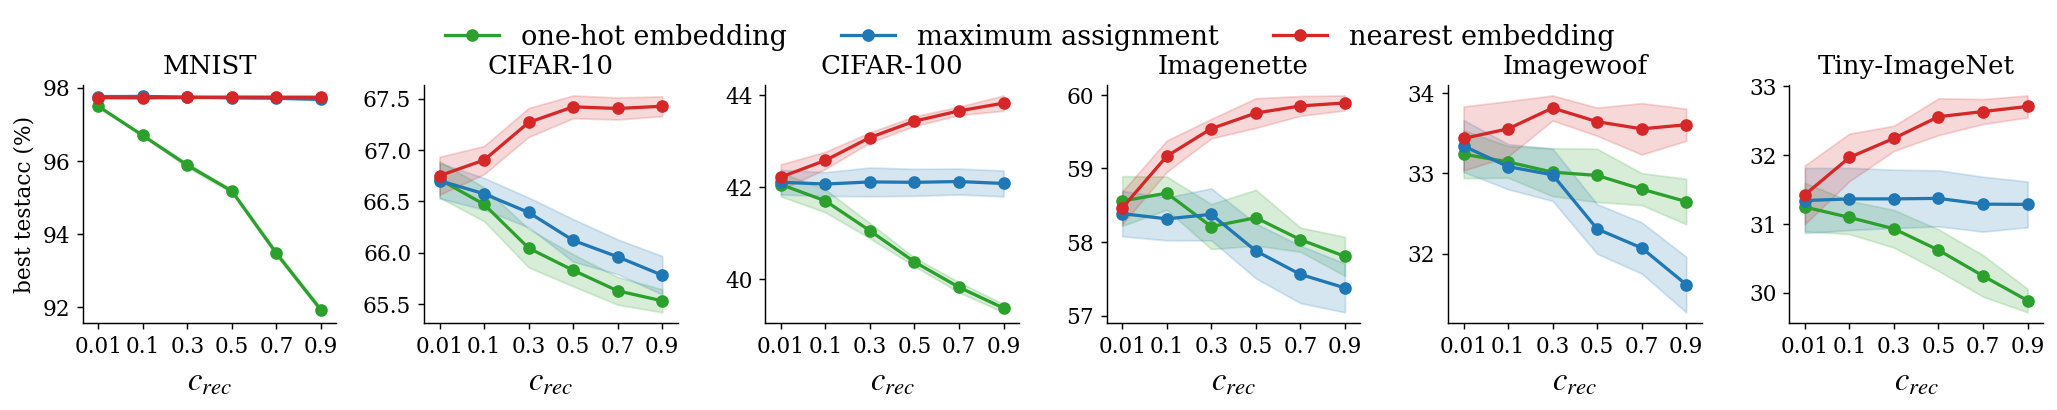

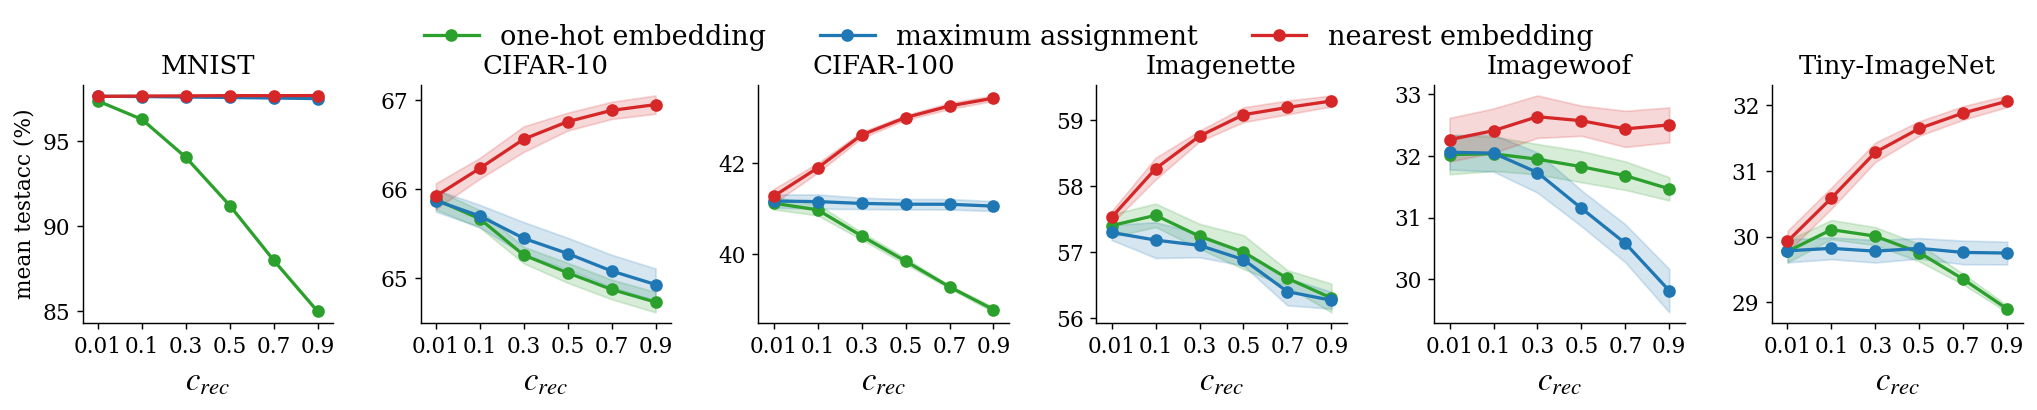

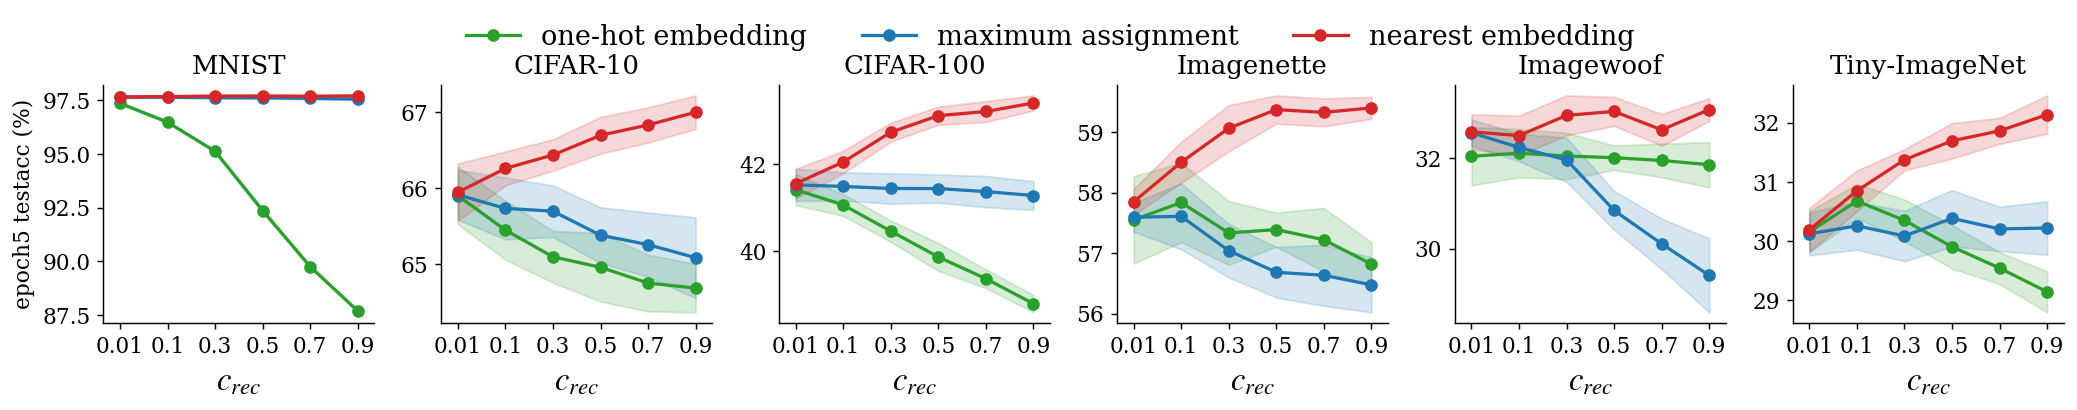

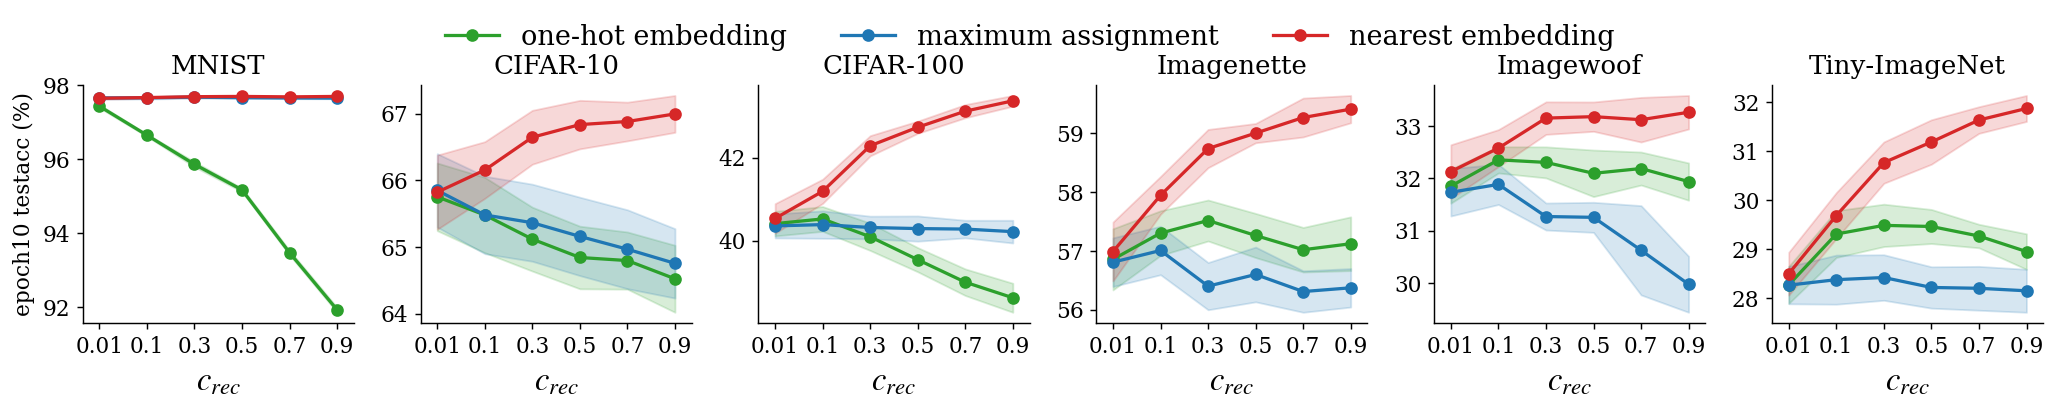

In [10]:
# ---------- Ablation: one row x six datasets ----------
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
})

ABLATION_LOG_DIR = Path("/data/dn/FRTP_revision1/imagecls/logs")
ablation_df = load_results(directory=ABLATION_LOG_DIR, include_ablation=True)
print(f"Loaded {len(ablation_df)} ablation seed-level runs from {ablation_df['source_file'].nunique() if not ablation_df.empty else 0} result files.")
# display(completeness_report(ablation_df).head(80))
ABLATION_METRICS = ["best_testacc", "mean_testacc", "epoch5_testacc", "epoch10_testacc"]
for metric in ABLATION_METRICS:
    fig, axes = plot_ablation_grid(ablation_df, metric=metric, datasets=DATASET_ORDER, figsize=(16, 3.0))
    fig.savefig(Path("/data/dn/FRTP_revision1/imagecls/logs_new") / f"ablation_{metric}_ci.pdf", bbox_inches="tight")
    plt.show()


## csv visualize

In [8]:
MLP_OFFLINE_FILE = "/data/dn/FRTP_revision1/imagecls/logs/results_offline__mlp.csv"

NAVSIM_METRICS = [
    "drivable_area_compliance",
    "ego_progress",
    "time_to_collision_within_bound",
    "comfort",
    "driving_direction_compliance",
    "score",
]
NAVSIM_METRIC_LABELS = {
    "drivable_area_compliance": "DAC$\\uparrow$",
    "ego_progress": "EP$\\uparrow$",
    "time_to_collision_within_bound": "TTC$\\uparrow$",
    "comfort": "Comfort$\\uparrow$",
    "driving_direction_compliance": "DDC$\\uparrow$",
    "score": "Score$\\uparrow$",
}
NAVSIM_LAYER_ORDER = {"baseline": -1, "out": 0, "recons_z3": 1, "recons_z2": 2, "recons_z1": 3}

def navsim_alpha_label(alpha):
    if pd.isna(alpha):
        return "--"
    return f"{float(alpha):g}"

def navsim_layer_label(recons_key):
    if recons_key == "baseline":
        return "baseline"
    if recons_key == "out":
        return "out"
    if str(recons_key).startswith("recons_z"):
        return str(recons_key).replace("recons_z", "z")
    return str(recons_key)

def navsim_format_value(mean, std=None, scale=100, bold=False, star=False):
    if pd.isna(mean):
        return "--"
    if std is None or pd.isna(std):
        body = f"{mean * scale:.2f}"
    else:
        body = f"{mean * scale:.2f} $\\pm$ {std * scale:.2f}"
    if bold:
        body = f"\\textbf{{{body}}}"
    if star:
        body += "$^{*}$"
    return body

def build_navsim_csv_table(csv_file=MLP_OFFLINE_FILE, metrics=NAVSIM_METRICS, scale=100, p_threshold=0.05):
    raw = pd.read_csv(csv_file).dropna(axis=1, how="all")
    baseline = raw[raw["recons_key"].eq("baseline")].iloc[0]
    work = raw[~raw["recons_key"].eq("baseline")].copy()
    work["seed"] = pd.to_numeric(work["seed"], errors="coerce").astype("Int64")
    work["alpha"] = pd.to_numeric(work["alpha"], errors="coerce")
    for metric in metrics:
        work[metric] = pd.to_numeric(work[metric], errors="coerce")

    summary = (
        work.groupby(["recons_key", "alpha"], as_index=False)[list(metrics)]
        .agg(["mean", "std"])
    )
    summary.columns = ["_".join(col).rstrip("_") for col in summary.columns]
    summary = summary.reset_index()
    summary["layer_sort"] = summary["recons_key"].map(NAVSIM_LAYER_ORDER).fillna(10_000)

    stat_rows = []
    best_flags = {}
    for rk, sg in summary.groupby("recons_key", sort=False):
        raw_group = work[work["recons_key"].eq(rk)]
        for metric in metrics:
            ordered = sg.sort_values(f"{metric}_mean", ascending=False)
            if ordered.empty:
                continue
            best = ordered.iloc[0]
            best_alpha = float(best["alpha"])
            if best_alpha != 0.0 and raw_group["alpha"].eq(0.0).any():
                comp_alpha = 0.0
                contrast = f"best vs alpha={navsim_alpha_label(comp_alpha)}"
            elif len(ordered) > 1:
                comp_alpha = float(ordered.iloc[1]["alpha"])
                contrast = f"alpha={navsim_alpha_label(best_alpha)} vs second alpha={navsim_alpha_label(comp_alpha)}"
            else:
                comp_alpha = np.nan
                contrast = "not available"

            test = {"n": np.nan, "mean_diff": np.nan, "p_ttest": np.nan, "cohens_dz": np.nan}
            if pd.notna(comp_alpha):
                a = raw_group[raw_group["alpha"].eq(best_alpha)][["seed", metric]].rename(columns={metric: "a"})
                b = raw_group[raw_group["alpha"].eq(comp_alpha)][["seed", metric]].rename(columns={metric: "b"})
                paired = a.merge(b, on="seed", how="inner").dropna()
                if len(paired) >= 2:
                    diff = paired["a"].to_numpy(float) - paired["b"].to_numpy(float)
                    _, p_t = stats.ttest_rel(paired["a"], paired["b"], alternative="greater")
                    dz = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
                    test = {"n": len(paired), "mean_diff": float(diff.mean()), "p_ttest": float(p_t), "cohens_dz": float(dz)}
            sig = bool(pd.notna(test["p_ttest"]) and test["p_ttest"] < p_threshold)
            best_flags[(rk, best_alpha, metric)] = sig
            stat_rows.append({"recons_key": rk, "layers": navsim_layer_label(rk), "metric": metric,
                              "best_alpha": best_alpha, "contrast": contrast, **test})

    metric_headers = [NAVSIM_METRIC_LABELS[m] for m in metrics]
    lines = [
        "\\begin{table}[tp]",
        "    \\centering",
        "    \\caption{NavSim offline MLP results. Values are mean $\\pm$ std over five seeds (\\%).}",
        "    \\label{tab:navsim_offline_mlp}",
        "    \\begin{tabular}{ll" + "c" * len(metrics) + "}",
        "    \\toprule",
        "    $l_{r}$ & $\\alpha$ & " + " & ".join(metric_headers) + ROW_END,
        "    \\midrule",
    ]
    baseline_cells = ["baseline", "--"] + [navsim_format_value(baseline[m], std=None, scale=scale) for m in metrics]
    lines.append("    " + " & ".join(baseline_cells) + ROW_END)
    lines.append("    \\midrule")

    for rk, rg in summary.sort_values(["layer_sort", "alpha"]).groupby("recons_key", sort=False):
        first_layer_row = True
        for _, row in rg.sort_values("alpha").iterrows():
            cells = [navsim_layer_label(rk) if first_layer_row else "", navsim_alpha_label(row["alpha"])]
            for metric in metrics:
                mean = row[f"{metric}_mean"]
                std = row[f"{metric}_std"]
                max_mean = rg[f"{metric}_mean"].max()
                is_best = pd.notna(mean) and np.isclose(mean, max_mean, rtol=1e-10, atol=1e-12)
                star = best_flags.get((rk, float(row["alpha"]), metric), False)
                cells.append(navsim_format_value(mean, std, scale=scale, bold=is_best, star=star))
            lines.append("    " + " & ".join(cells) + ROW_END)
            first_layer_row = False
        lines.append("    \\addlinespace[2pt]")
    lines += [
        "    \\bottomrule",
        "    \\end{tabular}",
        "    \\vspace{2pt}",
        "    \\footnotesize{$^{*}$ marks paired one-sided t-test significance at $p<0.05$ for the bolded best value against $\\alpha=0$ when the best uses $\\alpha>0$, otherwise against the second-best setting.}",
        "\\end{table}",
    ]
    return "\n".join(lines), pd.DataFrame(stat_rows), summary

mlp_offline_latex_table, mlp_offline_stats_table, mlp_offline_summary_table = build_navsim_csv_table()
print(mlp_offline_latex_table)
display(mlp_offline_stats_table)


\begin{table}[tp]
    \centering
    \caption{NavSim offline MLP results. Values are mean $\pm$ std over five seeds (\%).}
    \label{tab:navsim_offline_mlp}
    \begin{tabular}{llcccccc}
    \toprule
    $l_{r}$ & $\alpha$ & DAC$\uparrow$ & EP$\uparrow$ & TTC$\uparrow$ & Comfort$\uparrow$ & DDC$\uparrow$ & Score$\uparrow$ \\
    \midrule
    baseline & -- & 79.27 & 63.70 & 84.72 & 99.99 & 90.42 & 67.39 \\
    \midrule
    out & 0 & \textbf{78.54 $\pm$ 0.64} & \textbf{63.20 $\pm$ 0.40} & \textbf{83.33 $\pm$ 0.43} & \textbf{99.99 $\pm$ 0.00} & \textbf{90.64 $\pm$ 0.38} & \textbf{66.18 $\pm$ 0.64} \\
    \addlinespace[2pt]
    z3 & 0 & \textbf{78.00 $\pm$ 0.47} & \textbf{62.83 $\pm$ 0.42} & \textbf{83.41 $\pm$ 0.41} & \textbf{99.99 $\pm$ 0.00} & \textbf{90.92 $\pm$ 0.06}$^{*}$ & \textbf{65.78 $\pm$ 0.55} \\
     & 0.02 & 77.95 $\pm$ 0.42 & 62.79 $\pm$ 0.37 & 83.37 $\pm$ 0.38 & \textbf{99.99 $\pm$ 0.00} & 90.82 $\pm$ 0.05 & 65.73 $\pm$ 0.47 \\
     & 0.1 & 77.93 $\pm$ 0.45 & 62.75 $\pm$ 0

,recons_key,layers,metric,best_alpha,contrast,n,mean_diff,p_ttest,cohens_dz
0,out,out,drivable_area_compliance,0.00,not available,NaN,NaN,NaN,NaN
1,out,out,ego_progress,0.00,not available,NaN,NaN,NaN,NaN
2,out,out,time_to_collision_within_bound,0.00,not available,NaN,NaN,NaN,NaN
3,out,out,comfort,0.00,not available,NaN,NaN,NaN,NaN
4,out,out,driving_direction_compliance,0.00,not available,NaN,NaN,NaN,NaN
5,out,out,score,0.00,not available,NaN,NaN,NaN,NaN
6,recons_z1,z1,drivable_area_compliance,0.02,best vs alpha=0,5.0,0.000033,0.186950,0.447214
7,recons_z1,z1,ego_progress,0.00,alpha=0 vs second alpha=0.02,5.0,0.000011,0.454930,0.053912
8,recons_z1,z1,time_to_collision_within_bound,0.02,best vs alpha=0,5.0,0.000049,0.213160,0.395626
9,recons_z1,z1,comfort,0.00,alpha=0 vs second alpha=0.02,5.0,0.000000,NaN,NaN


## everyci10

recons_out ['epoch10_testacc', 'mean_testacc', 'best_testacc']


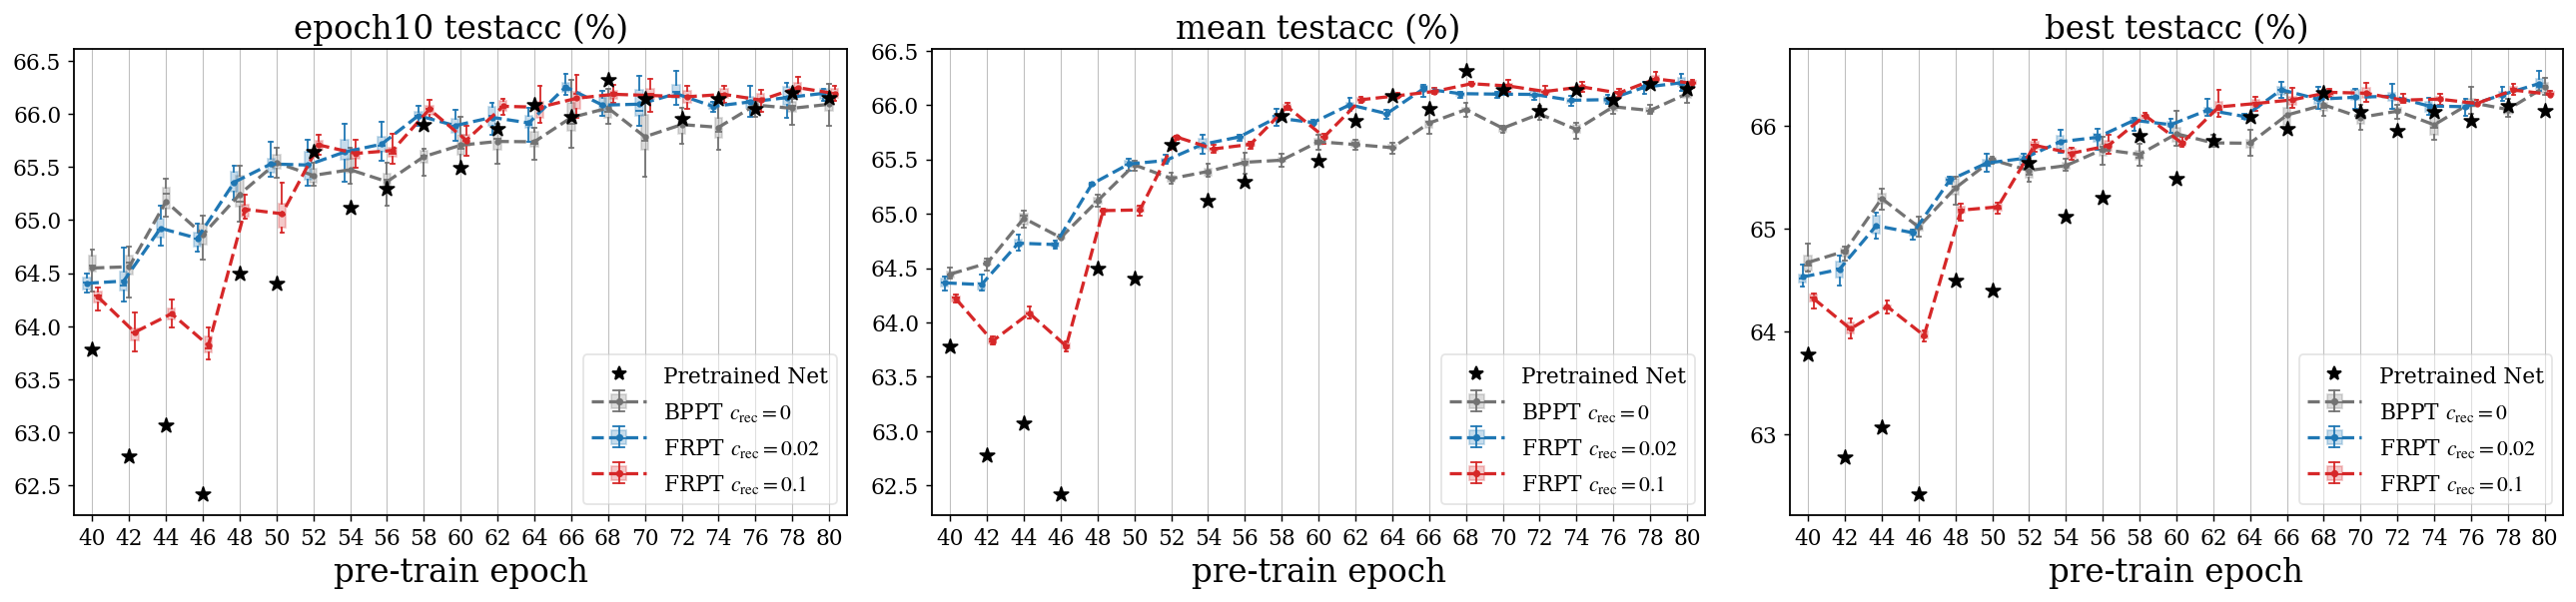

In [6]:
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
})

EVERYCI10_DIR = Path("/data/dn/FRTP_revision1/imagecls/logs_new/everyci10")
EVERYCI10_EPOCHS = range(40, 81, 2)
EVERYCI10_ALPHAS = [0, 0.02, 0.1]
EVERYCI10_RUNS = 10
EVERYCI10_RECONS_KEY = "recons_out"  # recons_out, recons_z4, recons_z3,recons_z2, recons_z1
EVERYCI10_METRICS = ["epoch10_testacc", "mean_testacc", "best_testacc"]
EVERYCI10_FIG_PATH = f"/data/dn/FRTP_revision1/imagecls/logs_new/everyci10_{EVERYCI10_RECONS_KEY}_metrics.pdf"
EVERYCI10_CSV_PATH = f"/data/dn/FRTP_revision1/imagecls/logs_new/everyci10_{EVERYCI10_RECONS_KEY}_metrics.csv"
print(EVERYCI10_RECONS_KEY, EVERYCI10_METRICS)

def parse_everyci10_filename(path):
    match = re.search(r"_e(\d+)_([0-9]*\.?[0-9]+)_10e$", Path(path).stem)
    if match is None:
        raise ValueError(f"Cannot parse epoch/baseline from filename: {Path(path).name}")
    return int(match.group(1)), float(match.group(2))


def everyci10_testacc_values(test_acc_ls):
    if test_acc_ls is None or len(test_acc_ls) == 0:
        return np.asarray([], dtype=float)
    values = []
    for value in test_acc_ls:
        if isinstance(value, dict):
            value = value.get("overall_acc", np.nan)
        values.append(as_float_or_nan(value))
    return np.asarray(values, dtype=float)


def everyci10_testacc_value(test_acc_ls, metric):
    values = everyci10_testacc_values(test_acc_ls)
    if values.size == 0:
        return np.nan
    if metric == "best_testacc":
        return np.nanmax(values)
    if metric == "mean_testacc":
        return np.nanmean(values)
    match = re.fullmatch(r"epoch(\d+)_testacc", str(metric))
    if match is not None:
        idx = int(match.group(1)) - 1
        return values[idx] if idx < len(values) else np.nan
    raise ValueError(
        f"Unknown metric={metric!r}. "
        "Use epoch1_testacc, epoch5_testacc, epoch10_testacc, best_testacc, or mean_testacc."
    )


pt_files = sorted(
    (path for path in EVERYCI10_DIR.glob("*.pt") if parse_everyci10_filename(path)[0] in EVERYCI10_EPOCHS),
    key=lambda path: parse_everyci10_filename(path)[0],
)
if len(pt_files) != len(EVERYCI10_EPOCHS):
    print(f"Warning: expected {len(EVERYCI10_EPOCHS)} .pt files, found {len(pt_files)} in {EVERYCI10_DIR}")

baseline_rows = []
alpha_rows = []

for pt_file in pt_files:
    epoch, baseline_testacc = parse_everyci10_filename(pt_file)
    baseline_rows.append({"epoch": epoch, "baseline_testacc": baseline_testacc, "source_file": str(pt_file)})

    records = _safe_torch_load(pt_file)
    if not isinstance(records, list):
        raise TypeError(f"Expected list records in {pt_file}, got {type(records)}")

    for rec in records:
        alpha = as_float_or_nan(rec.get("alpha", np.nan))
        if not any(np.isclose(alpha, target, rtol=1e-10, atol=1e-12) for target in EVERYCI10_ALPHAS):
            continue
        if rec.get("recons_key") != EVERYCI10_RECONS_KEY:
            continue
        row = {
            "epoch": epoch,
            "alpha": float(alpha),
            "seed": rec.get("seed", np.nan),
            "source_file": str(pt_file),
        }
        row.update({metric: everyci10_testacc_value(rec.get("test_acc_ls", []), metric) for metric in EVERYCI10_METRICS})
        alpha_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows).sort_values("epoch")
everyci10_df = pd.DataFrame(alpha_rows).sort_values(["alpha", "epoch", "seed"])
# everyci10_df.to_csv(EVERYCI10_CSV_PATH, index=False)

# At each epoch, plot the baseline test accuracy encoded in that checkpoint filename.

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class BoxplotMeanHandle:
    def __init__(self, color):
        self.color = color

class HandlerBoxplotMean(HandlerBase):
    def create_artists(self, legend, handle, xdescent, ydescent, width, height, fontsize, trans):
        color, x, y = handle.color, xdescent + width / 2, ydescent + height / 2
        x0, x1 = xdescent, xdescent + width
        y0, y1 = ydescent + 0.08 * height, ydescent + 0.92 * height
        bw, by, bh = 0.28 * width, ydescent + 0.22 * height, 0.56 * height
        kw = dict(color=color, linewidth=1, transform=trans)
        return [
            Line2D([x0, x1], [y, y], linestyle="--", linewidth=1.8, color=color, transform=trans),
            Line2D([x, x], [y0, y1], **kw),
            Line2D([x - bw / 3, x + bw / 3], [y0, y0], **kw),
            Line2D([x - bw / 3, x + bw / 3], [y1, y1], **kw),
            Rectangle((x - bw / 2, by), bw, bh, facecolor=color, edgecolor=color, alpha=0.25, transform=trans),
            Line2D([x - bw / 2, x + bw / 2], [by + 0.4 * bh] * 2, **kw),
            Line2D([x], [y], color=color, marker="o", markersize=3, linestyle="none", transform=trans),
        ]

fig, axes = plt.subplots(1, 3, figsize=(20, 4.8))
colors = {0: "0.45", 0.02: "tab:blue", 0.1: "tab:red"}
offsets = {0: 0, 0.02: -0.3, 0.1: 0.3}
legend_handles = [Line2D([], [], color="black", marker="*", linestyle="none", markersize=8)]
legend_labels = ["Pretrained Net"]
for alpha in EVERYCI10_ALPHAS:
    legend_handles.append(BoxplotMeanHandle(colors[alpha]))
    legend_labels.append(("FRPT " if alpha > 0 else "BPPT ") + rf"$c_{{\mathrm{{rec}}}}={alpha:g}$")
for i, (ax, metric) in enumerate(zip(axes, EVERYCI10_METRICS)):
    ax.scatter(baseline_df["epoch"], baseline_df["baseline_testacc"] * 100, color="black", marker="*", s=70, zorder=4)
    for alpha in EVERYCI10_ALPHAS:
        alpha_df = everyci10_df[np.isclose(everyci10_df["alpha"], alpha, rtol=1e-10, atol=1e-12)]
        values = [alpha_df.loc[alpha_df["epoch"] == epoch, metric].dropna().to_numpy() * 100 for epoch in EVERYCI10_EPOCHS]
        if any(len(value) != EVERYCI10_RUNS for value in values):
            print(f"Warning: {metric}, alpha={alpha:g} does not have {EVERYCI10_RUNS} valid runs at every epoch")
        positions = np.asarray(list(EVERYCI10_EPOCHS)) + offsets[alpha]
        bp = ax.boxplot(values, positions=positions, widths=0.4, patch_artist=True, showfliers=False, manage_ticks=False)
        for box in bp["boxes"]:
            box.set(facecolor=colors[alpha], edgecolor=colors[alpha], alpha=0.25)
        for key in ["whiskers", "caps", "medians"]:
            plt.setp(bp[key], color=colors[alpha])
        ax.plot(positions, [np.mean(value) if len(value) else np.nan for value in values], color=colors[alpha], linestyle="--", linewidth=1.8, marker="o", markersize=2.5, zorder=3)
    ax.set(title=metric.replace("_", " ")+" (%)", xlabel="pre-train epoch", ylabel="", xlim=(39, 81), xticks=EVERYCI10_EPOCHS)
    # ax.set(title=metric.replace("_", " "), xlabel="epoch", ylabel="testacc (%)" if i == 0 else "", xlim=(39, 81), xticks=EVERYCI10_EPOCHS)
    ax.set_title(metric.replace("_", " ") + " (%)", fontsize=18)
    ax.set_xlabel("pre-train epoch", fontsize=18)
    ax.grid(True, axis="x", linestyle="-", linewidth=0.6, alpha=0.8)
    for spine in ax.spines.values():
        spine.set(visible=True, color="black", linewidth=1)
    ax.legend(legend_handles, legend_labels, ncol=1, loc="lower right", facecolor="white", framealpha=0.5, handlelength=2.5, handleheight=1.4, handler_map={BoxplotMeanHandle: HandlerBoxplotMean()})
fig.tight_layout()
fig.savefig(EVERYCI10_FIG_PATH, bbox_inches="tight")
plt.show()

# display(Markdown(f"Saved figure to `{EVERYCI10_FIG_PATH}` and data to `{EVERYCI10_CSV_PATH}`."))
# display(everyci10_df.head())